In [63]:
import pandas as pd
import numpy as np


In [64]:
df = pd.read_csv("Churn_Modelling.csv")

df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [66]:
df.duplicated().sum()

np.int64(0)

In [67]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [68]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [69]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [70]:
df.drop(columns=['CustomerId','Surname','CreditScore'], inplace=True) #inplace=True will make the changes permanent

In [71]:
df

,RowNumber,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [72]:
# now we will do one hot encoding (it is used to transform data)
df = pd.get_dummies(df, columns=['Geography','Gender'], drop_first=True, dtype=int) # 
df 



,RowNumber,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,1,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,2,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,3,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,4,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,5,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,39,5,0.00,2,1,0,96270.64,0,0,0,1
9996,9997,35,10,57369.61,1,1,1,101699.77,0,0,0,1
9997,9998,36,7,0.00,1,0,1,42085.58,1,0,0,0
9998,9999,42,3,75075.31,2,1,0,92888.52,1,1,0,1


In [73]:
X = df.drop(columns=['Exited'])
y = df['Exited']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [74]:
X.shape

(10000, 11)

In [75]:
# now we perform scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [76]:
# now values are all scaled we are ready to import keras
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense


In [77]:
model = Sequential()

In [78]:
model.add(Dense(11, activation='relu', input_dim=11)) # 3hidden node and 11 input nodes
model.add(Dense(11, activation='relu'))
model.add(Dense(1, activation='sigmoid'))


C:\Users\kadia\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [79]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276 (1.08 KB)

 Trainable params: 276 (1.08 KB)

 Non-trainable params: 0 (0.00 B)

In [80]:
# now we compile the model, we will choose the loss function and optimizer

model.compile(loss='binary_crossentropy',optimizer='Adam', metrics=['accuracy'])
history = model.fit(X_train_scaler,y_train,epochs=100,validation_split=0.2)


Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6739 - loss: 0.6171 - val_accuracy: 0.7975 - val_loss: 0.5050
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7972 - loss: 0.4799 - val_accuracy: 0.7975 - val_loss: 0.4581
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7981 - loss: 0.4485 - val_accuracy: 0.7987 - val_loss: 0.4344
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8033 - loss: 0.4282 - val_accuracy: 0.8106 - val_loss: 0.4181
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8238 - loss: 0.4123 - val_accuracy: 0.8250 - val_loss: 0.3993
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8355 - loss: 0.3954 - val_accuracy: 0.8406 - val_loss: 0.3812
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8452 - loss: 0.3798 - val_accuracy: 0.8537 - val_loss: 0.3665
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8481 - loss: 0.3685 - val_accu

In [81]:
import matplotlib.pyplot as plt
history.history

{'accuracy': [0.6739062666893005,
  0.7971875071525574,
  0.7981250286102295,
  0.8032812476158142,
  0.8237500190734863,
  0.8354687690734863,
  0.8451562523841858,
  0.8481249809265137,
  0.8525000214576721,
  0.854687511920929,
  0.8540624976158142,
  0.8568750023841858,
  0.8568750023841858,
  0.8578125238418579,
  0.8592187762260437,
  0.8595312237739563,
  0.860156238079071,
  0.8604687452316284,
  0.859375,
  0.8628125190734863,
  0.862500011920929,
  0.8610937595367432,
  0.8623437285423279,
  0.8617187738418579,
  0.86328125,
  0.8609374761581421,
  0.8628125190734863,
  0.862500011920929,
  0.86328125,
  0.8629687428474426,
  0.8653125166893005,
  0.8635937571525574,
  0.8648437261581421,
  0.8656250238418579,
  0.8657812476158142,
  0.8642187714576721,
  0.8656250238418579,
  0.8653125166893005,
  0.8637499809265137,
  0.8654687404632568,
  0.8642187714576721,
  0.8646875023841858,
  0.8645312786102295,
  0.8651562333106995,
  0.8656250238418579,
  0.8673437237739563,
  0.86

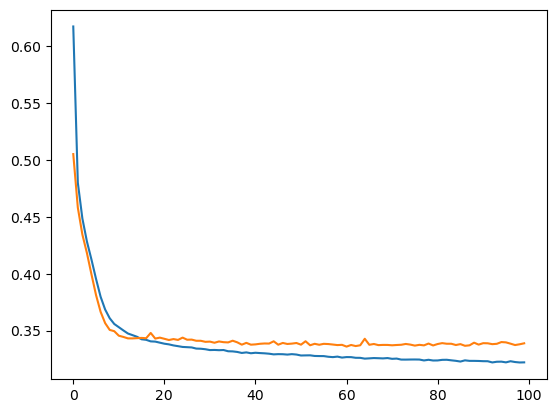

In [82]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

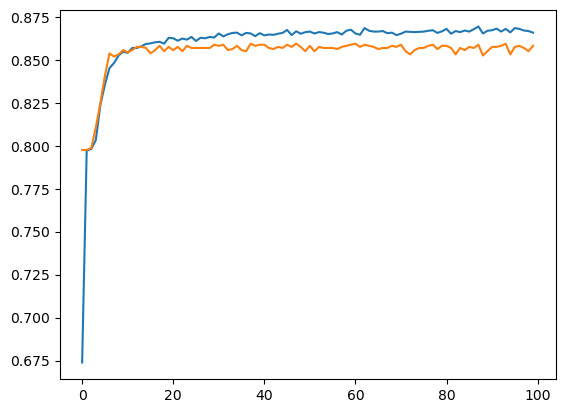

In [83]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [84]:
model.layers[0].get_weights() # input layer

[array([[-0.16113792, -0.11608424, -0.38927862, -0.22273974,  0.27357444,
         -0.09791955,  0.11491275,  0.0301022 , -0.30100223, -0.4521926 ,
          0.22479291],
        [ 0.00761044, -0.6777789 ,  0.0624977 ,  0.19633028,  0.79665124,
          0.14829934,  0.19224583, -0.8478271 , -0.32804266,  0.2755819 ,
          0.44174138],
        [ 0.15952384, -0.14073566, -0.03216441, -0.04440346,  0.16156258,
         -0.2515448 ,  0.14256416,  0.03324656, -0.02897283,  0.25723076,
          0.59750414],
        [ 0.22386687, -0.18861789, -0.6869235 ,  0.45664898,  0.14286403,
          0.22951582, -0.74059635,  0.11335666, -0.18037517, -0.13626723,
          0.1480039 ],
        [ 1.0382186 , -0.14718807, -0.67840177,  0.71107674,  0.06539434,
         -0.58493793, -0.25628644,  0.07751432,  1.3675559 ,  0.35433042,
         -0.7428362 ],
        [ 0.01064488,  0.97163534,  0.3349769 , -0.4080339 ,  0.07741024,
          0.25672248, -0.6449703 , -0.06677073, -0.2006813 , -0.1824034

In [85]:
model.layers[1].get_weights() # hidden layer

[array([[ 0.22200653, -0.45888907,  0.3451129 ,  0.03669216, -0.9477535 ,
         -0.9401257 ,  0.6796328 , -0.4822026 , -0.45966482,  0.3837699 ,
          0.03555693],
        [ 0.15852404,  0.30116662,  0.5531955 ,  0.1495097 ,  0.17805384,
          0.241737  , -0.5294349 ,  0.28499264, -0.7722032 ,  0.32021132,
          0.68676364],
        [-1.0142751 , -0.13351847, -0.17102702, -0.87451524,  0.21123074,
         -0.16855095, -0.77524453,  0.06314491,  0.11934818,  0.23842326,
         -0.10263947],
        [ 0.6139752 , -0.1291859 , -0.23374358,  0.4988684 ,  0.00954791,
         -0.47790417,  0.03089936, -0.26548478,  0.40615556,  0.55305177,
         -0.17371221],
        [ 0.03215564, -0.5119656 ,  0.70264447, -0.96121836, -0.73910713,
          0.20851773,  0.333042  ,  0.889026  , -0.4294572 , -0.23447144,
          0.3593451 ],
        [ 0.08944555, -0.04998107, -0.303698  ,  0.1035431 ,  0.235957  ,
         -0.05306914, -1.0307271 , -0.21566445,  0.06463746,  0.5938355

In [86]:
# we can predict because our model has calculated all the weights and bias

y_log = model.predict(X_test_scaler) #instead of X_train_scaler there would be X_test_scaler

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [87]:
y_pred = np.where(y_log>0.5,1,0)

In [88]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(2000, 1))

In [89]:
# now we will check accuracy of the model
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.858

In [ ]:
# 1st accuracy is 0.7925
# 2nd accuracy is 0.858